In [2]:
library(tidyverse)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.1     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Read in Data

In [3]:
yelp <- read_csv("yelp_data.csv")
head(yelp)

Rows: 175000 Columns: 8
-- Column specification --------------------------------------------------------
Delimiter: ","
chr  (6): Treatment, Desktop, LocalService, Eligible, AdShown, AdClick
dbl  (1): Revenue
date (1): Date

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


Treatment,Desktop,LocalService,Eligible,AdShown,AdClick,Revenue,Date
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<date>
control,mobile,non-local,eligible,shown,clicked,1.41,2019-01-01
control,mobile,non-local,eligible,shown,not clicked,0.00,2019-01-01
control,mobile,local,eligible,shown,not clicked,0.00,2019-01-01
control,mobile,local,eligible,shown,clicked,5.57,2019-01-01
treatment,mobile,non-local,eligible,shown,clicked,1.29,2019-01-01
treatment,desktop,local,eligible,shown,clicked,5.90,2019-01-01


## Exploratory Data Analysis


    local non-local 
0.6000629 0.3999371 


  desktop    mobile 
0.2983429 0.7016571 


    eligible not eligible 
  0.95077714   0.04922286 


not shown     shown 
0.2005943 0.7994057 


    clicked not clicked 
  0.6415257   0.3584743 

[1] 2.760595

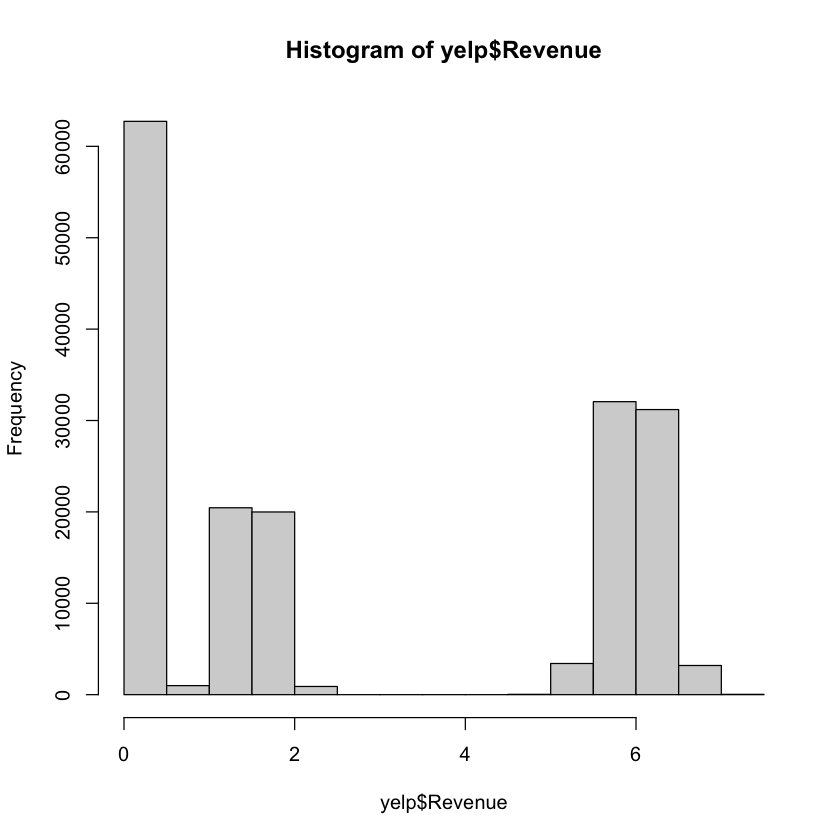

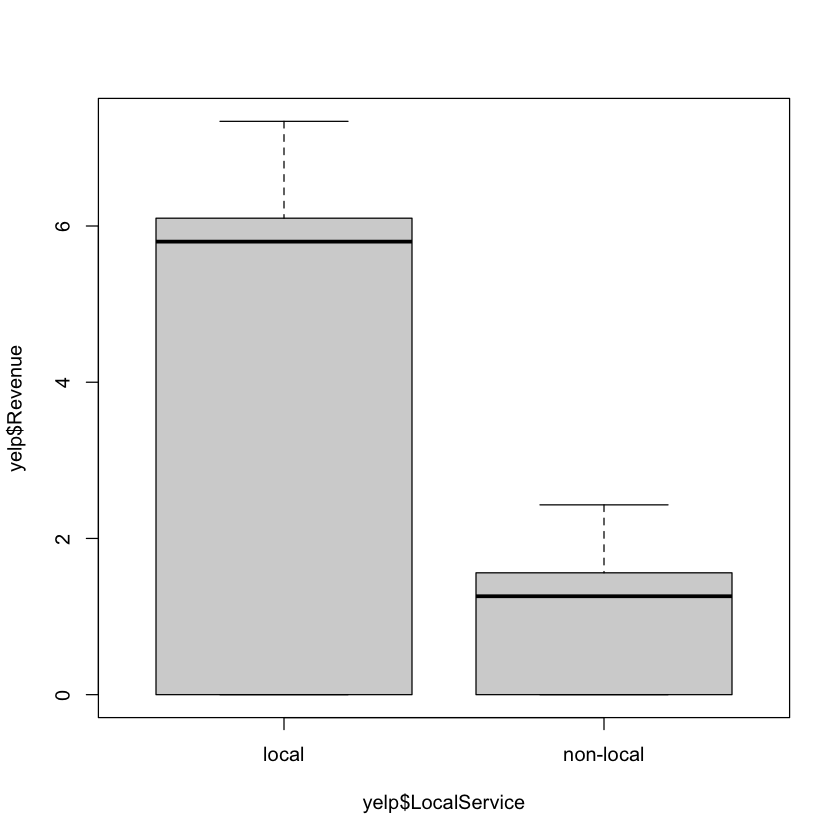

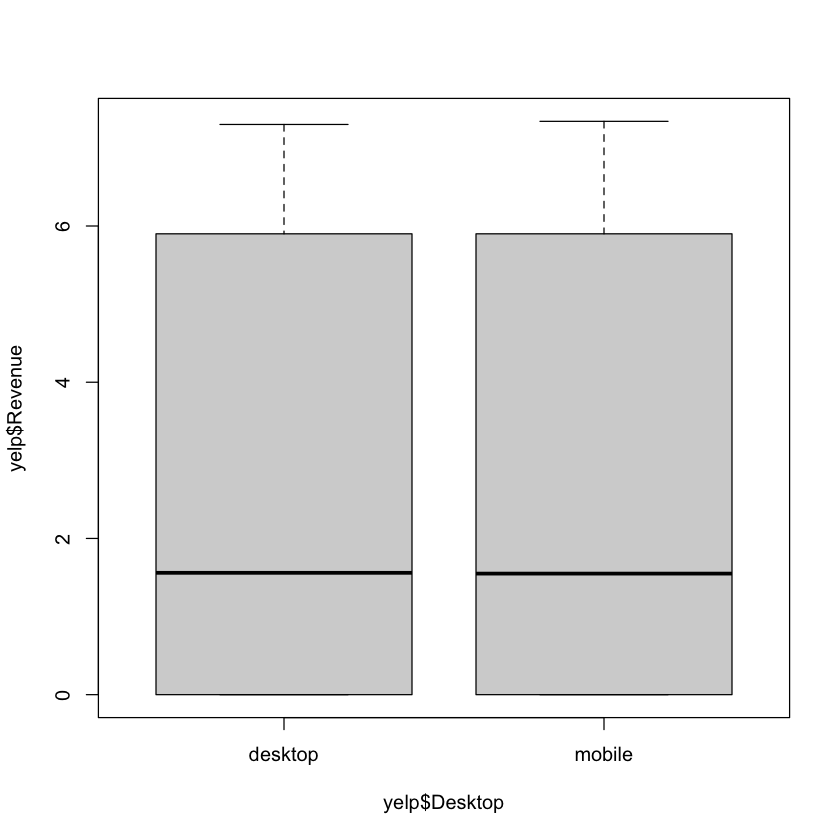

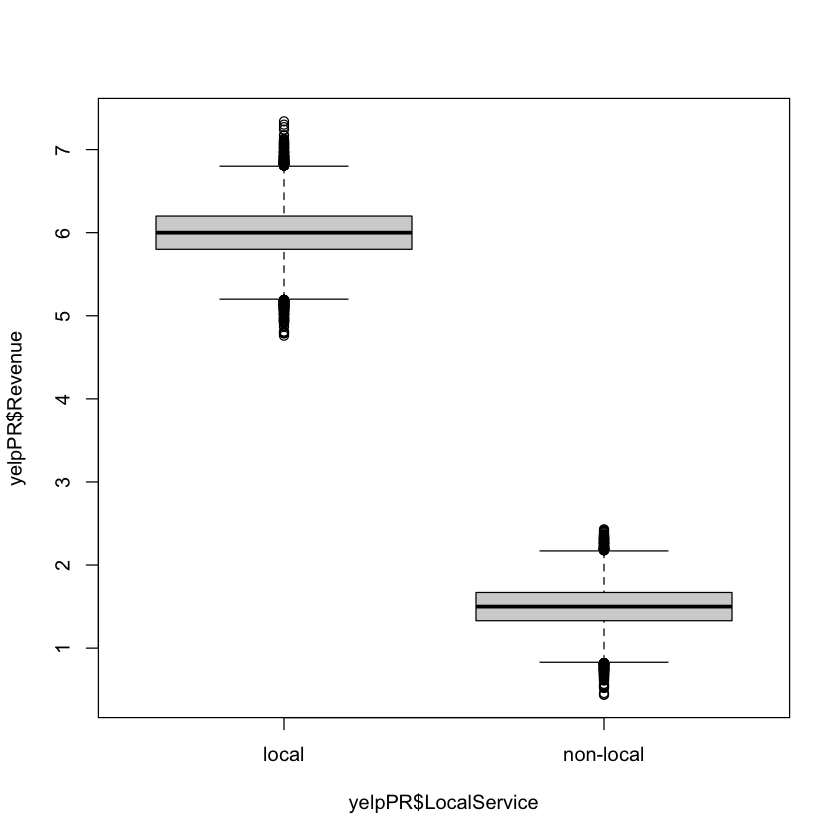

In [4]:
prop.table(table(yelp$LocalService))
prop.table(table(yelp$Desktop))
prop.table(table(yelp$Eligible))
prop.table(table(yelp$AdShown))
prop.table(table(yelp$AdClick))
mean(yelp$Revenue)
hist(yelp$Revenue)
boxplot(yelp$Revenue ~ yelp$LocalService)
boxplot(yelp$Revenue ~ yelp$Desktop)
yelpPR <- filter(yelp, Revenue > 0)
boxplot(yelpPR$Revenue ~ yelpPR$LocalService)

# Distinguishing the Difference Between Eligible Searches

## Step 1: Visualization

              
               control treatment
  eligible       82988     83398
  not eligible    4377      4237

              
                  control  treatment
  eligible     0.94989985 0.95165174
  not eligible 0.05010015 0.04834826

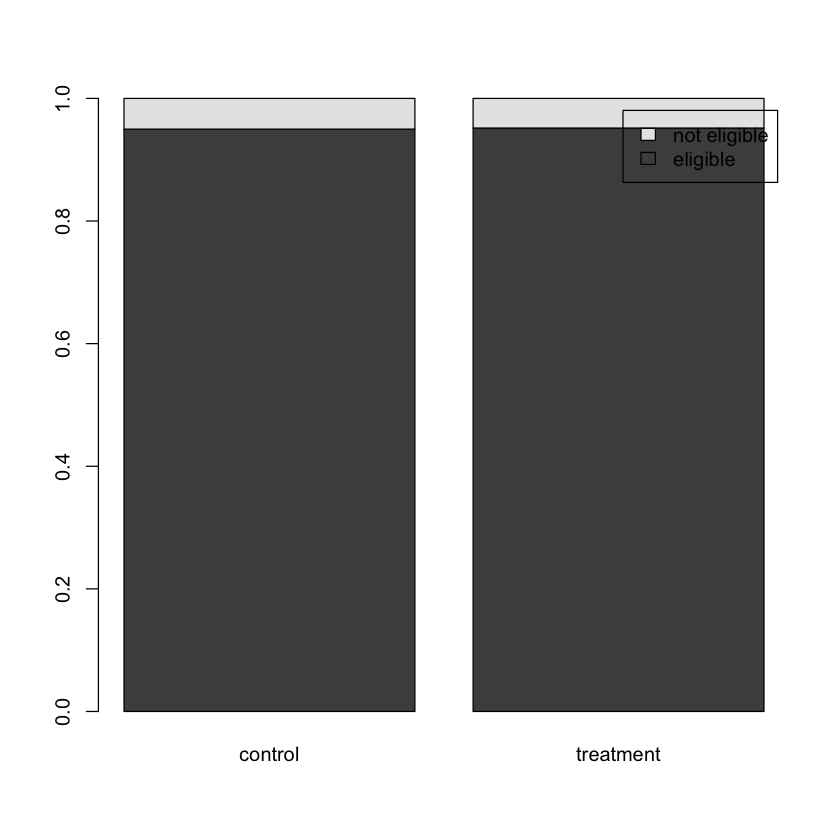

In [5]:
table(yelp$Eligible, yelp$Treatment)
prop.table(table(yelp$Eligible, yelp$Treatment), 2)
eligibilityTable <- prop.table(table(yelp$Eligible, yelp$Treatment), 2)
barplot(eligibilityTable, legend = rownames(eligibilityTable))

## Step 2: Conduct Hypothesis Test

In [ ]:
t.test((yelp$AdClick == "clicked") ~ yelp$Treatment)



	Welch Two Sample t-test

data:  (yelp$AdClick == "clicked") by yelp$Treatment
t = 33.408, df = 174656, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.07186638 0.08082454
sample estimates:
  mean in group control mean in group treatment 
              0.6797573               0.6034119 


In [6]:
#t.test()
t.test((yelp$Eligible == "eligible") ~ yelp$Treatment)

#prop.test()
addmargins(table(yelp$Eligible, yelp$Treatment), 1)
prop.test(x = c(82988, 83398), n = c(87365, 87635))


	Welch Two Sample t-test

data:  (yelp$Eligible == "eligible") by yelp$Treatment
t = -1.6938, df = 174928, p-value = 0.0903
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.0037790871  0.0002753034
sample estimates:
  mean in group control mean in group treatment 
              0.9498998               0.9516517 


,control,treatment
eligible,82988,83398
not eligible,4377,4237
Sum,87365,87635



	2-sample test for equality of proportions with continuity correction

data:  c(82988, 83398) out of c(87365, 87635)
X-squared = 2.8318, df = 1, p-value = 0.09242
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.0037904901  0.0002867064
sample estimates:
   prop 1    prop 2 
0.9498998 0.9516517 


# Shown Rate for Eligible Searches

## Step 1: Subset to Eligible Searches

In [7]:
eligible <- filter(yelp, Eligible == "eligible")
head(eligible)

Treatment,Desktop,LocalService,Eligible,AdShown,AdClick,Revenue,Date
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<date>
control,mobile,non-local,eligible,shown,clicked,1.41,2019-01-01
control,mobile,non-local,eligible,shown,not clicked,0.00,2019-01-01
control,mobile,local,eligible,shown,not clicked,0.00,2019-01-01
control,mobile,local,eligible,shown,clicked,5.57,2019-01-01
treatment,mobile,non-local,eligible,shown,clicked,1.29,2019-01-01
treatment,desktop,local,eligible,shown,clicked,5.90,2019-01-01


## Step 2: Visualization

           
              control treatment
  not shown 0.1046987 0.2961944
  shown     0.8953013 0.7038056

           
               control  treatment
  not shown 0.05747819 0.26043790
  shown     0.94252181 0.73956210

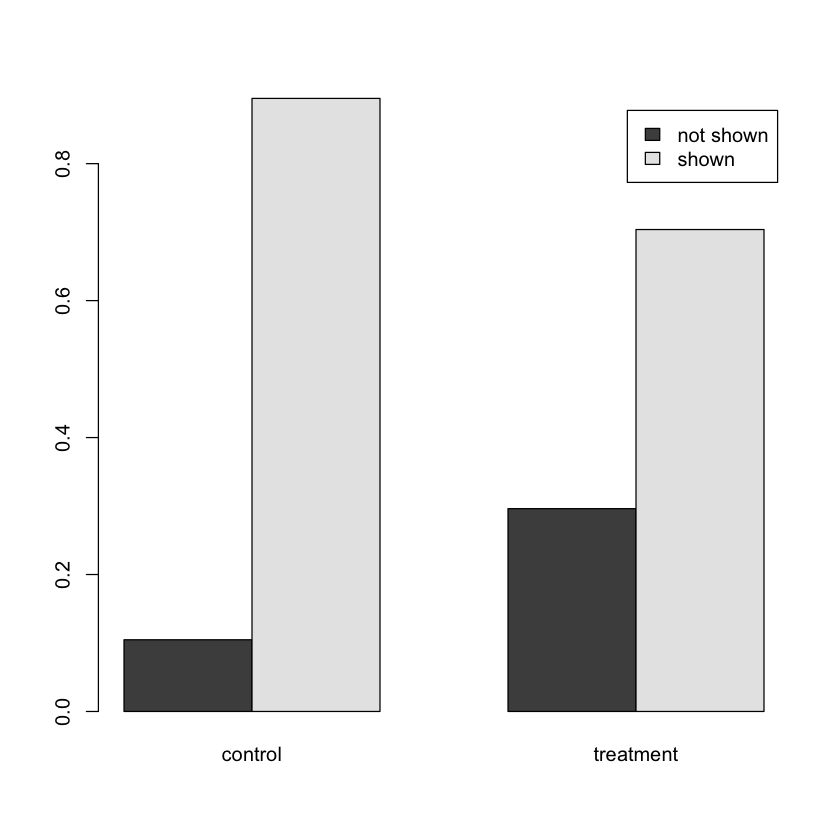

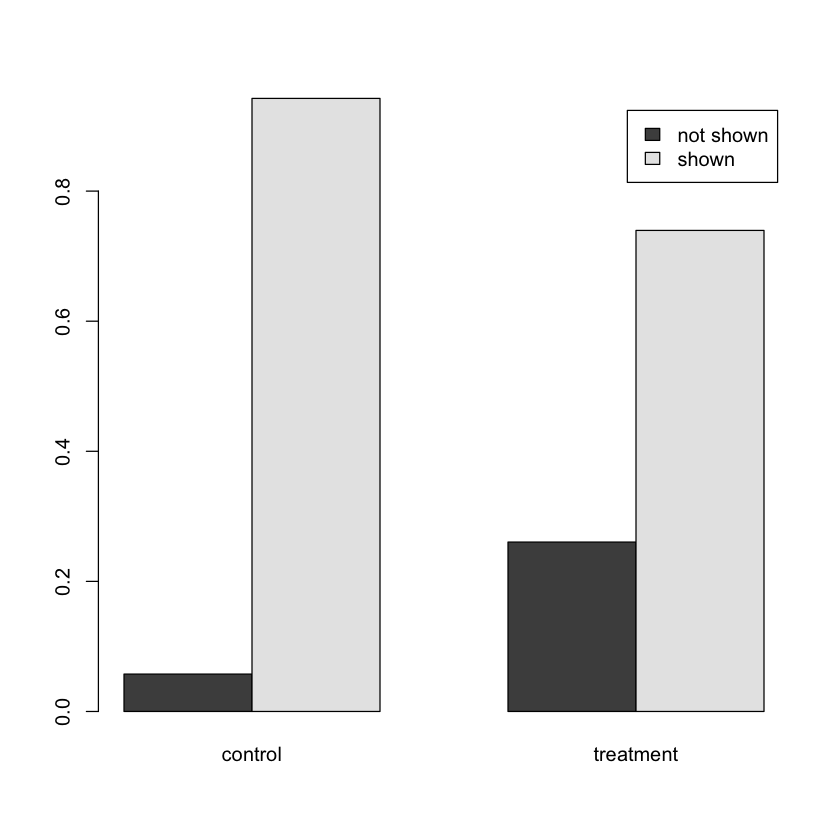

In [8]:
prop.table(table(yelp$AdShown, yelp$Treatment), 2)
yelpTreatmentTable <- prop.table(table(yelp$AdShown, yelp$Treatment), 2)
barplot(yelpTreatmentTable, beside = TRUE, legend = rownames(yelpTreatmentTable))

prop.table(table(eligible$AdShown, eligible$Treatment), 2)
treatmentTable <- prop.table(table(eligible$AdShown, eligible$Treatment), 2)
barplot(treatmentTable, beside = TRUE, legend = rownames(treatmentTable))

## Step 3: Conduct hypothesis test

In [9]:
#t.test()
t.test((eligible$AdShown == "shown") ~ eligible$Treatment)

#prop.test()
addmargins(table(eligible$AdShown, eligible$Treatment))
prop.test(x = c(78218, 61678), n = c(82988, 83398))


	Welch Two Sample t-test

data:  (eligible$AdShown == "shown") by eligible$Treatment
t = 117.92, df = 127008, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.1995863 0.2063331
sample estimates:
  mean in group control mean in group treatment 
              0.9425218               0.7395621 


,control,treatment,Sum
not shown,4770,21720,26490
shown,78218,61678,139896
Sum,82988,83398,166386



	2-sample test for equality of proportions with continuity correction

data:  c(78218, 61678) out of c(82988, 83398)
X-squared = 12799, df = 1, p-value < 2.2e-16
alternative hypothesis: two.sided
95 percent confidence interval:
 0.1995743 0.2063451
sample estimates:
   prop 1    prop 2 
0.9425218 0.7395621 


# Clickthrough Rate for Searches that Showed Advertisements


	Welch Two Sample t-test

data:  (eligible$AdClick == "clicked") by eligible$Treatment
t = 35.64, df = 165776, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.07705727 0.08602577
sample estimates:
  mean in group control mean in group treatment 
              0.7156095               0.6340680 


             
                control treatment
  clicked     0.7156095 0.6340680
  not clicked 0.2843905 0.3659320

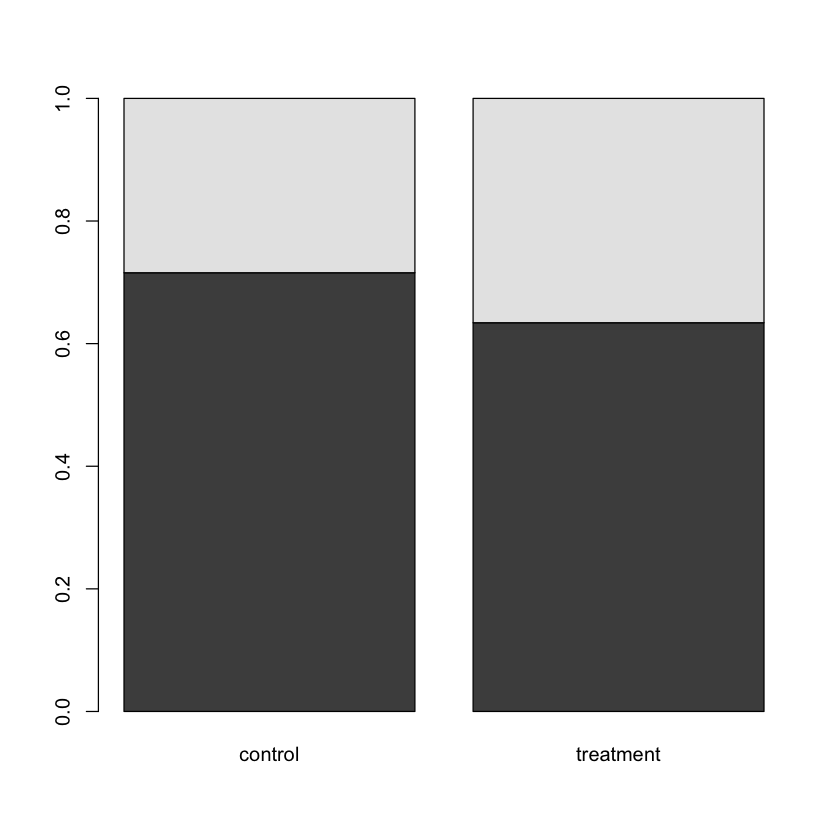

In [10]:
t.test((eligible$AdClick == "clicked") ~ eligible$Treatment)
prop.table(table(eligible$AdClick, eligible$Treatment), 2)
barplot(prop.table(table(eligible$AdClick, eligible$Treatment), 2))

# Shown Rate for Searches foe Eligible Advertisements


	Welch Two Sample t-test

data:  (shown$AdClick == "clicked") by shown$Treatment
t = -47.202, df = 139708, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.1021798 -0.0940325
sample estimates:
  mean in group control mean in group treatment 
              0.7592498               0.8573559 


             
                control treatment
  clicked     0.7592498 0.8573559
  not clicked 0.2407502 0.1426441

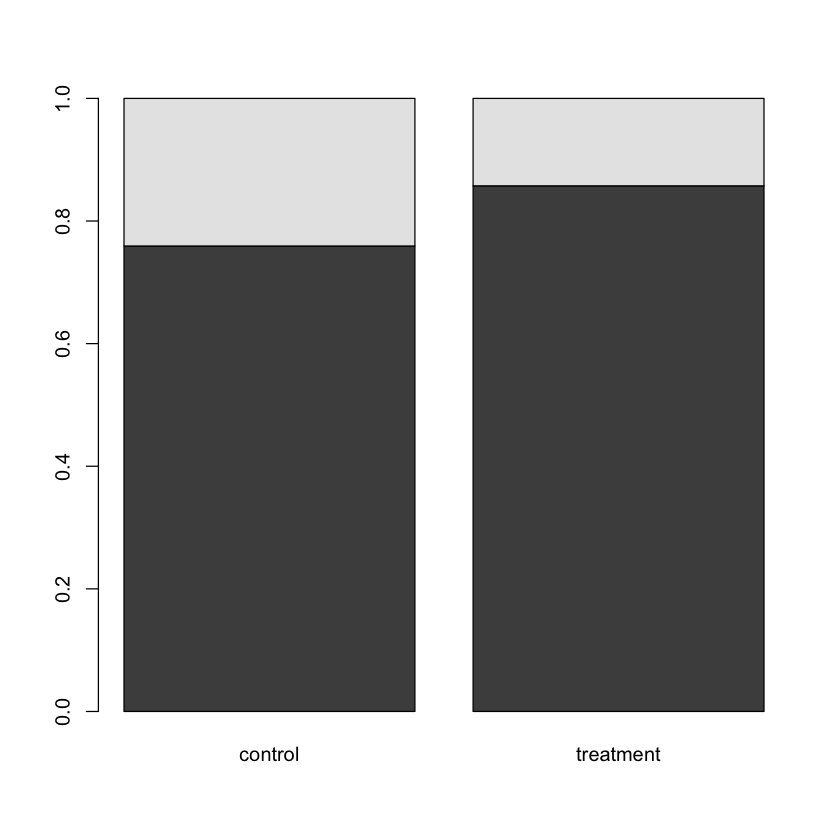

In [11]:
shown <- filter(eligible, AdShown == "shown")
t.test((shown$AdClick == "clicked") ~ shown$Treatment)
prop.table(table(shown$AdClick, shown$Treatment), 2)
barplot(prop.table(table(shown$AdClick, shown$Treatment), 2))

# Revenue Metrics


	Welch Two Sample t-test

data:  eligible$Revenue by eligible$Treatment
t = 38.536, df = 166351, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.4833249 0.5351249
sample estimates:
  mean in group control mean in group treatment 
               3.158755                2.649530 


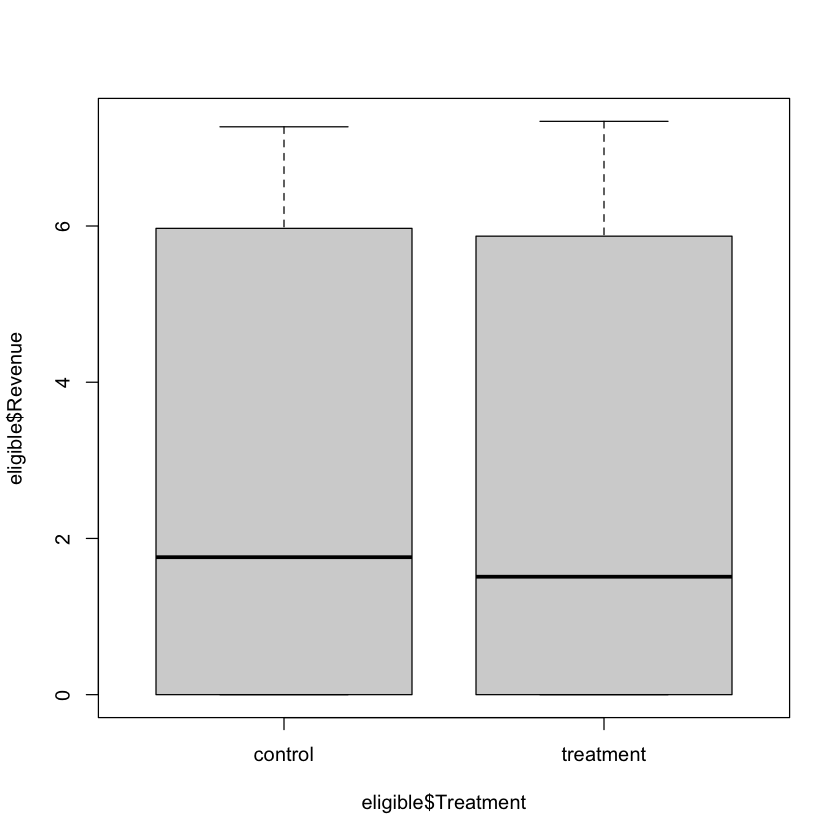

In [12]:
boxplot(eligible$Revenue ~ eligible$Treatment)
t.test(eligible$Revenue ~ eligible$Treatment)


	Welch Two Sample t-test

data:  clicked$Revenue by clicked$Treatment
t = 17.902, df = 110022, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.2096766 0.2612333
sample estimates:
  mean in group control mean in group treatment 
               4.414076                4.178621 



  control treatment 
    59387     52880 

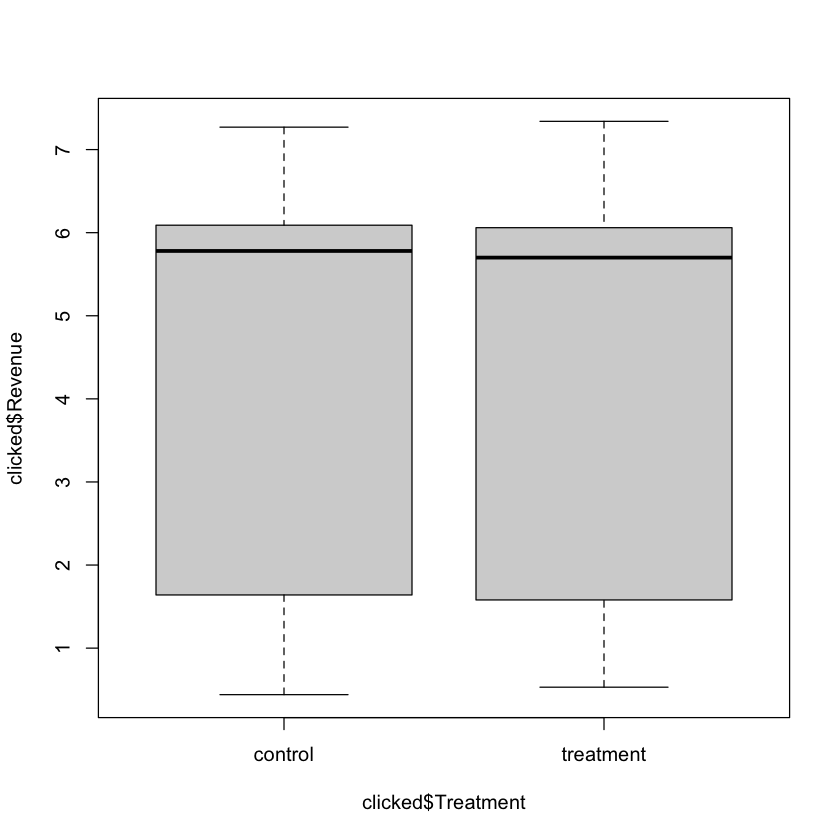

In [13]:
clicked <- filter(eligible, AdClick == "clicked")
boxplot(clicked$Revenue ~ clicked$Treatment)
t.test(clicked$Revenue ~ clicked$Treatment)

# ads clicked count
table(clicked$Treatment)


	Welch Two Sample t-test

data:  yelp$Revenue by yelp$Treatment
t = 37.075, df = 174919, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.4537447 0.5043972
sample estimates:
  mean in group control mean in group treatment 
               3.000500                2.521429 


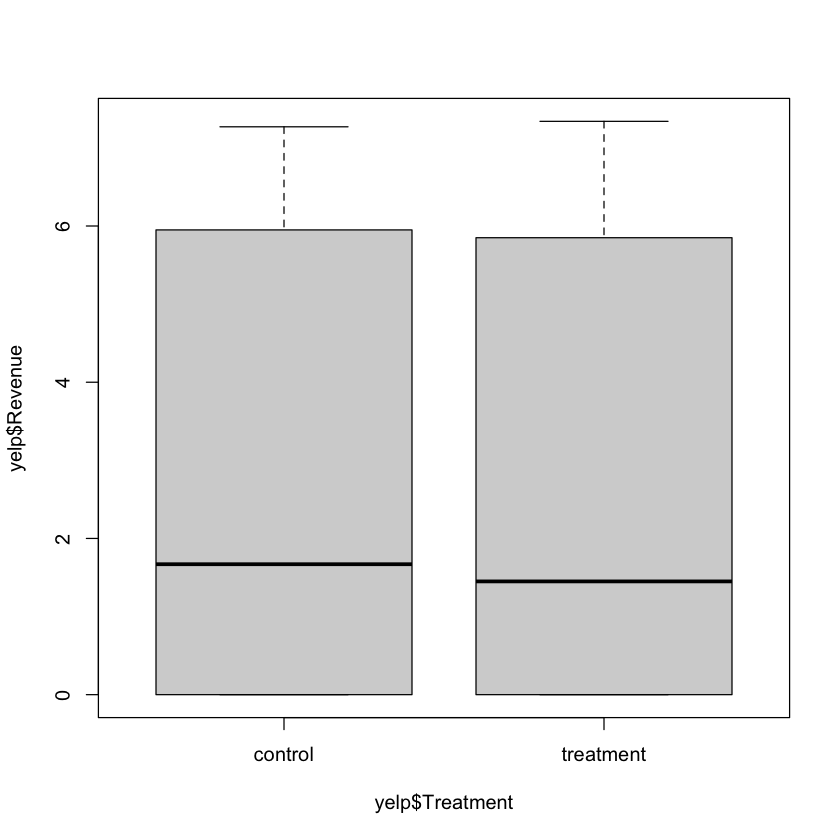


	Welch Two Sample t-test

data:  shown$Revenue by shown$Treatment
t = -16.566, df = 135352, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.2585315 -0.2038271
sample estimates:
  mean in group control mean in group treatment 
               3.351386                3.582565 


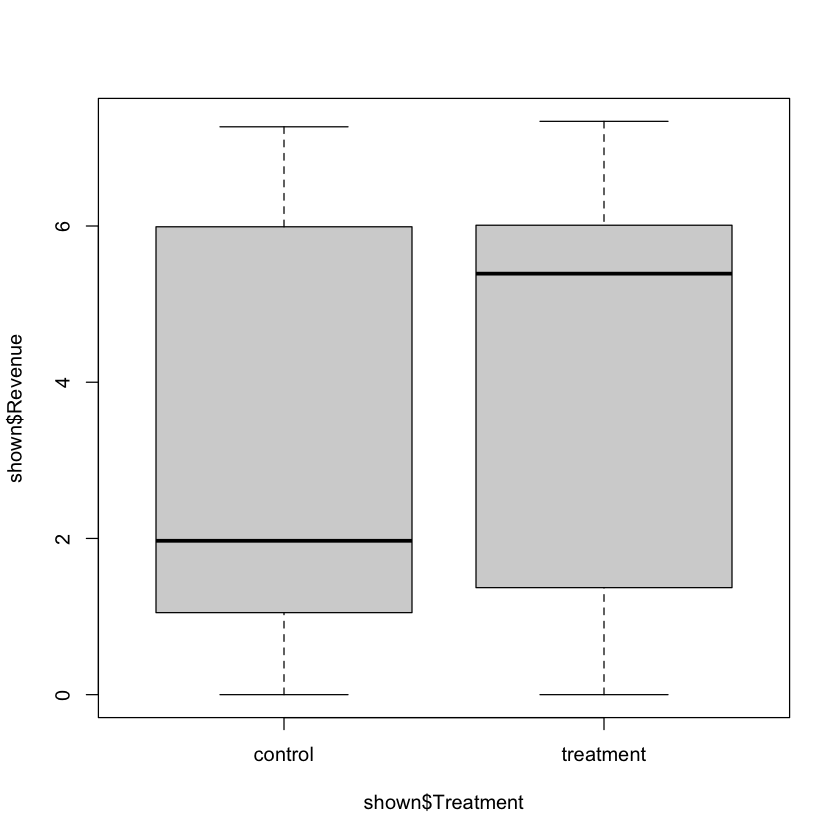

In [14]:
# revenue per ad without filtering by subset
boxplot(yelp$Revenue ~ yelp$Treatment)
t.test(yelp$Revenue ~ yelp$Treatment)

# revenue per shown ad
boxplot(shown$Revenue ~ shown$Treatment)
t.test(shown$Revenue ~ shown$Treatment)


	Welch Two Sample t-test

data:  yelp$Revenue by yelp$Treatment
t = 37.075, df = 174919, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.4537447 0.5043972
sample estimates:
  mean in group control mean in group treatment 
               3.000500                2.521429 



	Welch Two Sample t-test

data:  eligible$Revenue by eligible$Treatment
t = 38.536, df = 166351, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.4833249 0.5351249
sample estimates:
  mean in group control mean in group treatment 
               3.158755                2.649530 



	Welch Two Sample t-test

data:  shown$Revenue by shown$Treatment
t = -16.566, df = 135352, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.2585315 -0.2038271
sample estimates:
  mean in group control mean in group treatment 
               3.351386                3.582565 



	Welch Two Sample t-test

data:  clicked$Revenue by clicked$Treatment
t = 17.902, df = 110022, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.2096766 0.2612333
sample estimates:
  mean in group control mean in group treatment 
               4.414076                4.178621 


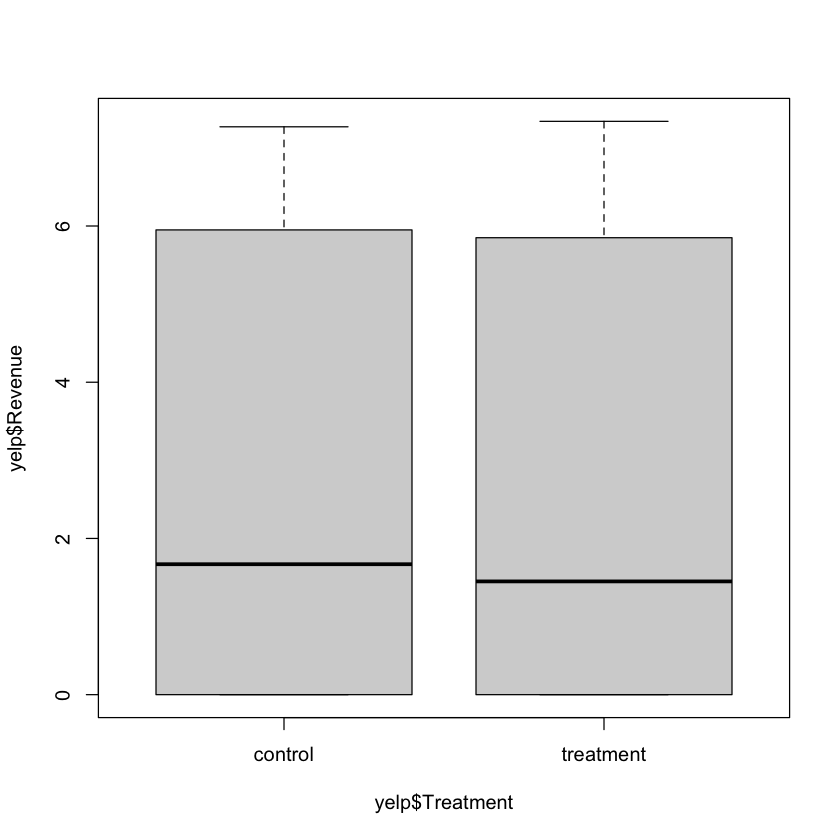

In [34]:
# revenue per ad without filtering by subset
boxplot(yelp$Revenue ~ yelp$Treatment)
t.test(yelp$Revenue ~ yelp$Treatment)

# Revenue per eligible
eligible <- filter(yelp, Eligible == "eligible")
t.test(eligible$Revenue ~ eligible$Treatment)

# Revenue per shown
shown <- filter(yelp, AdShown == "shown")
t.test(shown$Revenue ~ shown$Treatment)

# Revenue per click
clicked <- filter(yelp, AdClick == "clicked")
t.test(clicked$Revenue ~ clicked$Treatment)

# Heterogeous Analysis

## Local Services

In [15]:
local <- filter(yelp, LocalService == "local")

## Shown Rate for Eligible Local Searches


	Welch Two Sample t-test

data:  eligibleLocal$AdShown == "shown" by eligibleLocal$Treatment
t = 111.63, df = 71034, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.2483838 0.2572620
sample estimates:
  mean in group control mean in group treatment 
              0.9515663               0.6987434 


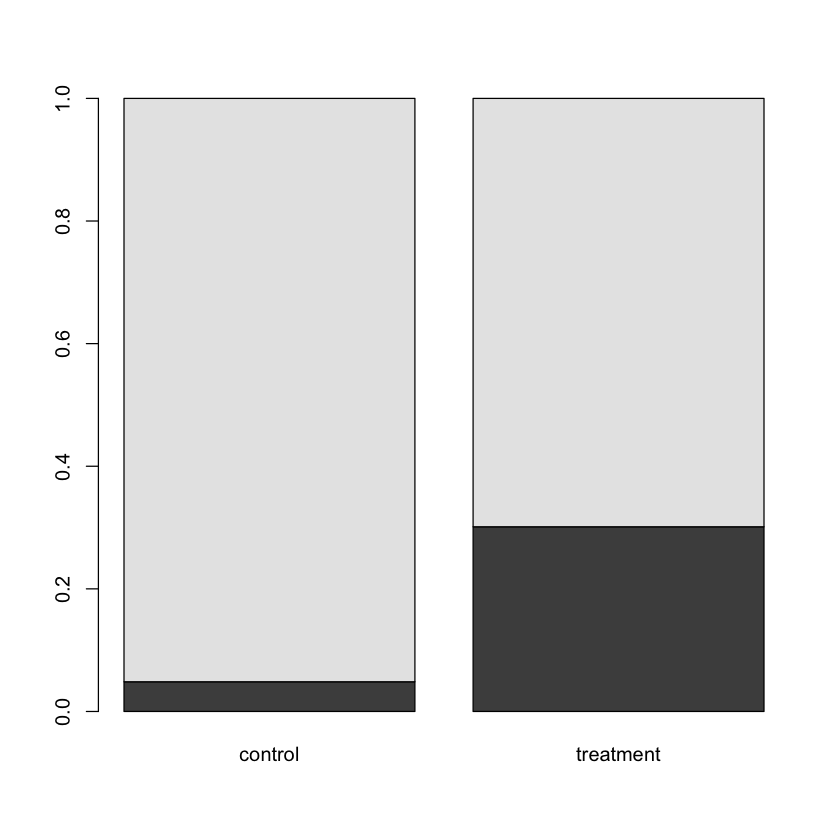

In [16]:
eligibleLocal <- filter(local, Eligible == "eligible")
barplot(prop.table(table(eligibleLocal$AdShown, eligibleLocal$Treatment), 2))
t.test(eligibleLocal$AdShown == "shown" ~ eligibleLocal$Treatment)

# Clickthrough Rate for Searches that Showed Ads


	Welch Two Sample t-test

data:  shownLocal$AdClick == "clicked" by shownLocal$Treatment
t = -37.023, df = 82301, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.09398525 -0.08453438
sample estimates:
  mean in group control mean in group treatment 
              0.8105887               0.8998485 


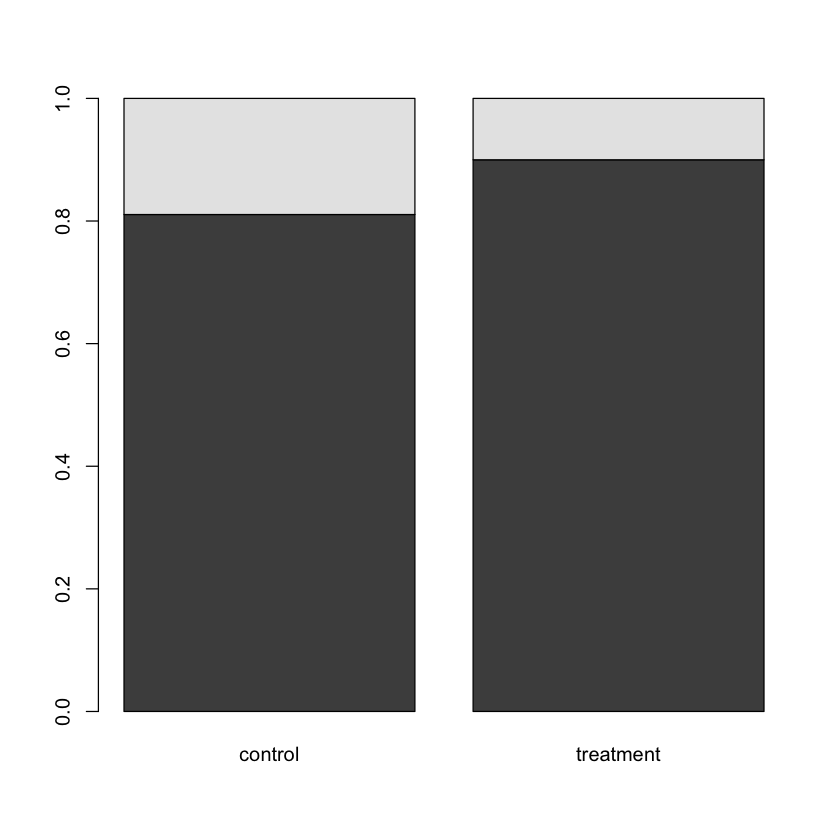

In [17]:
shownLocal <- filter(local, AdShown == "shown")
barplot(prop.table(table(shownLocal$AdClick, shownLocal$Treatment), 2))
t.test(shownLocal$AdClick == "clicked" ~ shownLocal$Treatment)

# Revenue Generated per Eligible Ad


	Welch Two Sample t-test

data:  eligibleLocal$Revenue by eligibleLocal$Treatment
t = 49.545, df = 98168, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.8211394 0.8887833
sample estimates:
  mean in group control mean in group treatment 
               4.627955                3.772994 


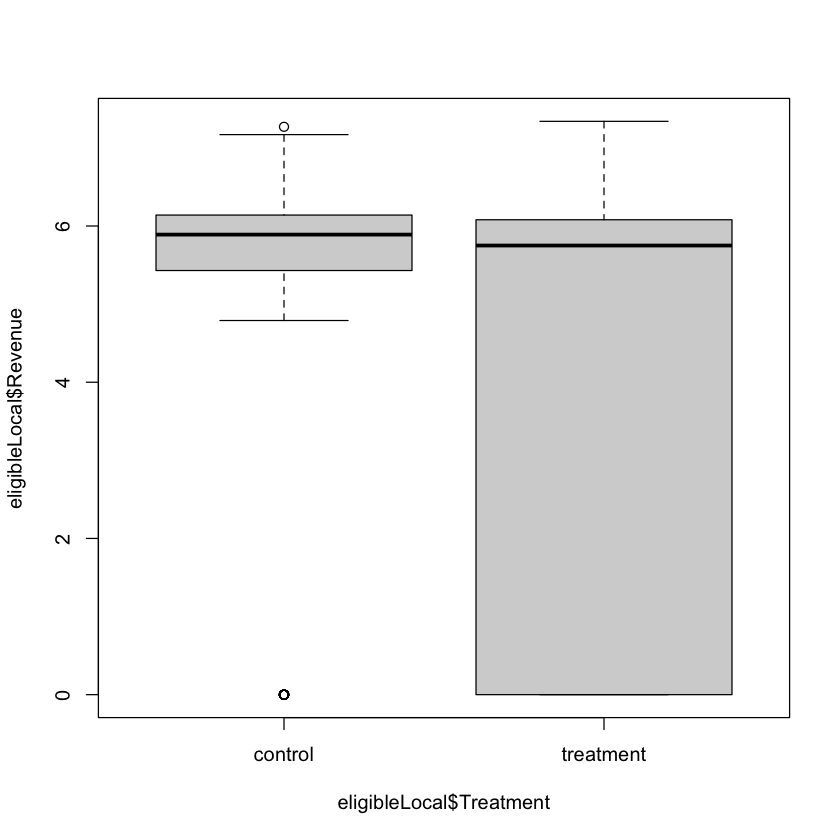

In [18]:
boxplot(eligibleLocal$Revenue ~ eligibleLocal$Treatment)
t.test(eligibleLocal$Revenue ~ eligibleLocal$Treatment)

# Revenue Generated per Ad Clicked

In [19]:
clickedLocal <- filter(shownLocal, AdClick == "clicked")
t.test(clickedLocal$Revenue ~ clickedLocal$Treatment)
table(clickedLocal$Treatment)


	Welch Two Sample t-test

data:  clickedLocal$Revenue by clickedLocal$Treatment
t = -0.29944, df = 67016, p-value = 0.7646
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.005151585  0.003786119
sample estimates:
  mean in group control mean in group treatment 
               5.999977                6.000660 



  control treatment 
    38460     31474 

# Total Revenue

In [20]:
# ads clicked count
table(clickedLocal$Treatment)


  control treatment 
    38460     31474 

# Non-Local Services

In [21]:
nonlocal <- filter(yelp, LocalService == "non-local")

# Shown Rate for Eligible Non-Local Searches


	Welch Two Sample t-test

data:  eligibleNonLocal$AdShown == "shown" by eligibleNonLocal$Treatment
t = 49.191, df = 56962, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 0.1229594 0.1331646
sample estimates:
  mean in group control mean in group treatment 
              0.9289078               0.8008458 


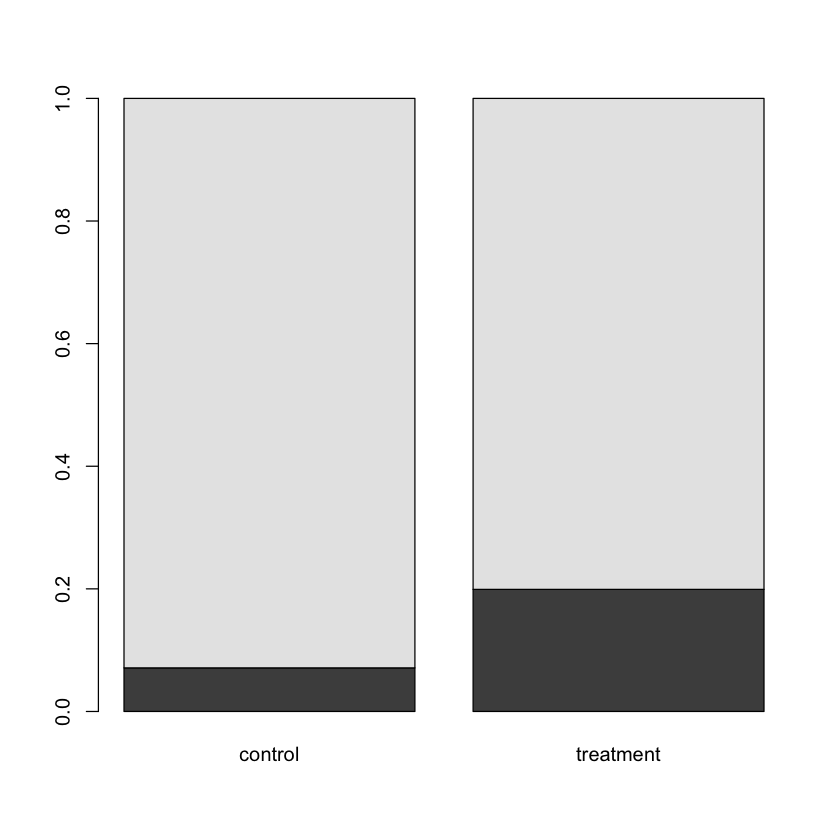

In [22]:
eligibleNonLocal <- filter(nonlocal, Eligible == "eligible")
barplot(prop.table(table(eligibleNonLocal$AdShown, eligibleNonLocal$Treatment), 2))
t.test(eligibleNonLocal$AdShown == "shown" ~ eligibleNonLocal$Treatment)

# Clickthrough Rate for Searches that Showed Ads


	Welch Two Sample t-test

data:  shownNonLocal$AdClick == "clicked" by shownNonLocal$Treatment
t = -33.694, df = 57457, p-value < 2.2e-16
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.1286782 -0.1145307
sample estimates:
  mean in group control mean in group treatment 
              0.6800884               0.8016928 


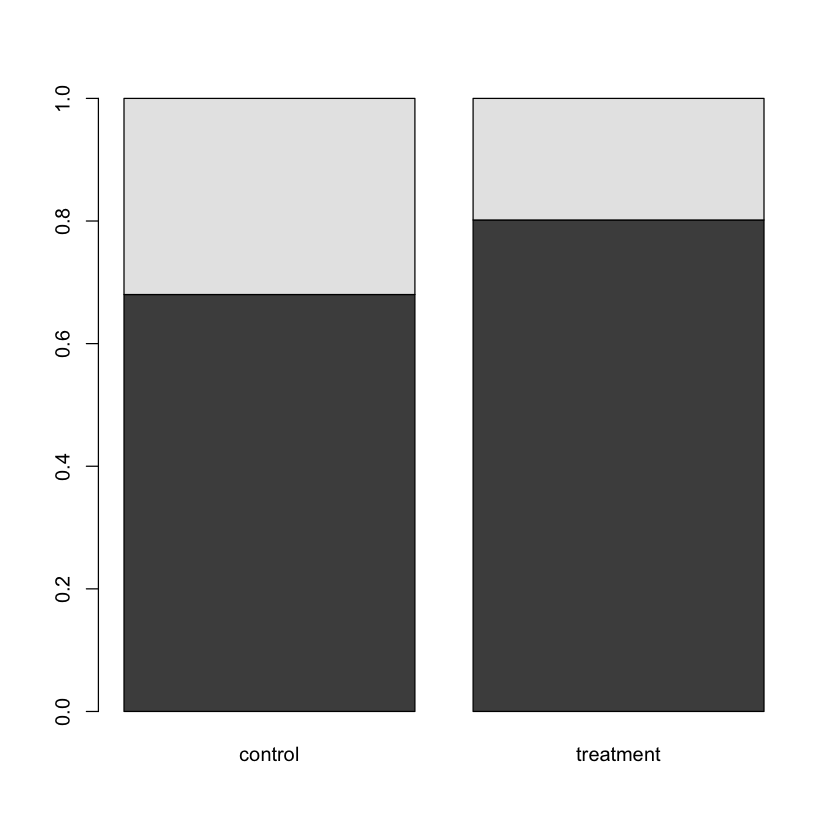

In [23]:
shownNonLocal <- filter(nonlocal, AdShown == "shown")
barplot(prop.table(table(shownNonLocal$AdClick, shownNonLocal$Treatment), 2))
t.test(shownNonLocal$AdClick == "clicked" ~ shownNonLocal$Treatment)

# Revenue Generated per Eligible Ad


	Welch Two Sample t-test

data:  eligibleNonLocal$Revenue by eligibleNonLocal$Treatment
t = -2.6742, df = 66456, p-value = 0.007494
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.026894356 -0.004144588
sample estimates:
  mean in group control mean in group treatment 
              0.9472804               0.9627999 


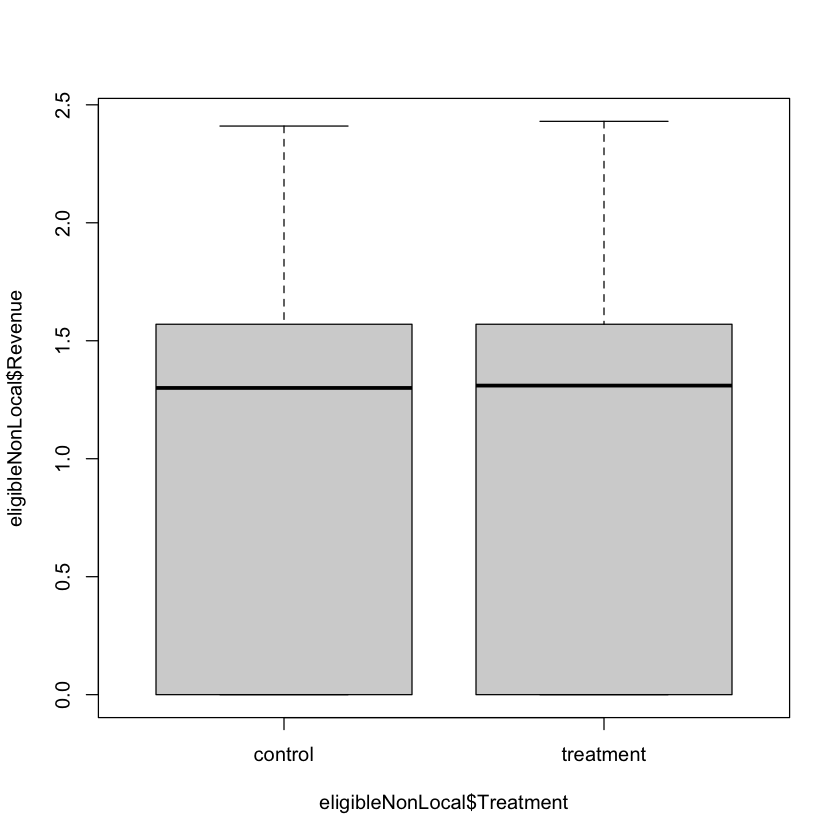

In [24]:
boxplot(eligibleNonLocal$Revenue ~ eligibleNonLocal$Treatment)
t.test(eligibleNonLocal$Revenue ~ eligibleNonLocal$Treatment)

# Revenue Generated per Ad Clicked

In [25]:
clickedNonLocal <- filter(shownNonLocal, AdClick == "clicked")
t.test(clickedNonLocal$Revenue ~ clickedNonLocal$Treatment)
table(clickedNonLocal$Treatment)


	Welch Two Sample t-test

data:  clickedNonLocal$Revenue by clickedNonLocal$Treatment
t = -0.054864, df = 42313, p-value = 0.9562
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -0.004888319  0.004622108
sample estimates:
  mean in group control mean in group treatment 
               1.499480                1.499613 



  control treatment 
    20927     21406 

# Total Revenue

In [26]:
# ads clicked count
table(clickedNonLocal$Treatment)


  control treatment 
    20927     21406 